## 1. Impor Library yang Diperlukan
Kita akan menggunakan beberapa library Python populer untuk memproses data teks dan membuat model klasifikasi. Sebagai contoh, seperti yang sudah dijelaskan pada pertemuan awal tentang pandas numpy dan sklearn

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import string
import re

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.naive_bayes import MultinomialNB, BernoulliNB
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from wordcloud import WordCloud


## 2. Membaca Dataset
Setelah meng import library python selanjut nya kita akan memanggil file Dataset yang saya sudah ambil dr github dengan source link : https://github.com/kopylovvlad/python_spam_detection .Dataset ini berisi pesan SMS yang diklasifikasikan sebagai spam atau ham (bukan spam).

In [3]:
# Membaca dataset
df = pd.read_csv("smspam.csv", encoding='latin-1')[['v1', 'v2']]
df.columns = ['label', 'teks']
df['label'] = df['label'].map({'ham': 0, 'spam': 1})  # 0 = ham, 1 = spam
df.head()


,label,teks
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


## 3. Eksplorasi Data Awal
Kita akan melihat distribusi data dan panjang rata-rata pesan. Dan saya akan menampilkan nya dalam bentuk grafik

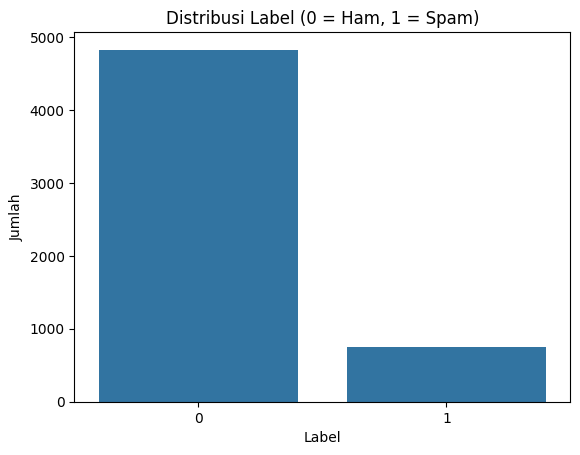

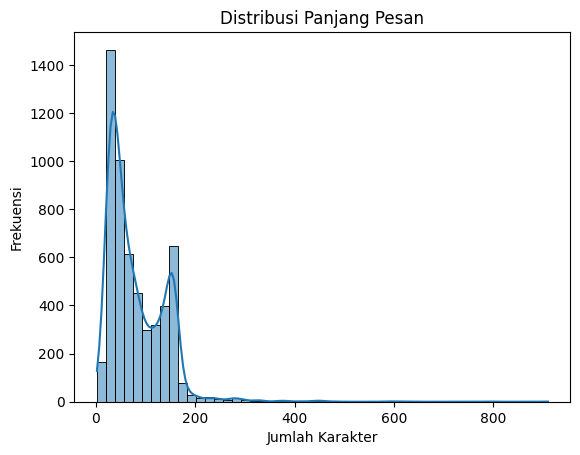

In [4]:
# Distribusi label
sns.countplot(data=df, x='label')
plt.title('Distribusi Label (0 = Ham, 1 = Spam)')
plt.xlabel('Label')
plt.ylabel('Jumlah')
plt.show()

# Panjang pesan
df['panjang_pesan'] = df['teks'].apply(len)
sns.histplot(df['panjang_pesan'], bins=50, kde=True)
plt.title('Distribusi Panjang Pesan')
plt.xlabel('Jumlah Karakter')
plt.ylabel('Frekuensi')
plt.show()


## 4. Visualisasi WordCloud
Lalu kita visualisasikan kata-kata yang sering muncul di pesan spam dan ham.

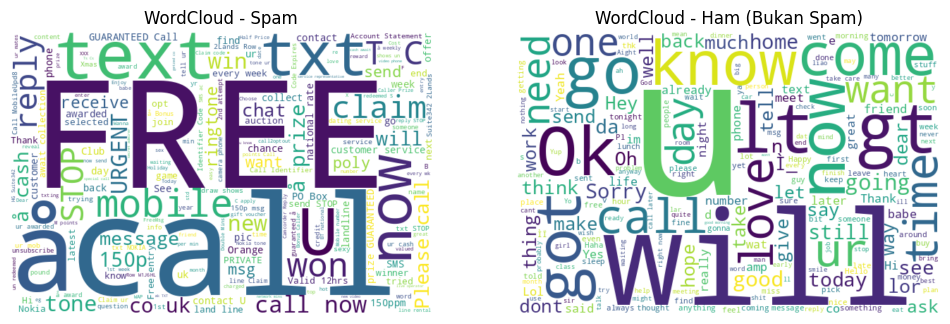

In [5]:
# Wordcloud untuk spam
spam_words = ' '.join(df[df['label'] == 1]['teks'])
ham_words = ' '.join(df[df['label'] == 0]['teks'])

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.imshow(WordCloud(width=600, height=400, background_color='white').generate(spam_words), interpolation='bilinear')
plt.axis('off')
plt.title('WordCloud - Spam')

plt.subplot(1, 2, 2)
plt.imshow(WordCloud(width=600, height=400, background_color='white').generate(ham_words), interpolation='bilinear')
plt.axis('off')
plt.title('WordCloud - Ham (Bukan Spam)')
plt.show()


## 5. Preprocessing Teks
Kita bersihkan teks dengan menghilangkan karakter spesial, angka, dan stopwords.

In [6]:
import nltk
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
nltk.download('stopwords')

stop_words = set(stopwords.words('english'))
stemmer = PorterStemmer()

def bersihkan_teks(teks):
    teks = teks.lower()
    teks = re.sub(r'[0-9]', '', teks)
    teks = teks.translate(str.maketrans('', '', string.punctuation))
    teks = ' '.join([stemmer.stem(kata) for kata in teks.split() if kata not in stop_words])
    return teks

df['teks_bersih'] = df['teks'].apply(bersihkan_teks)
df[['teks', 'teks_bersih']].head()


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


,teks,teks_bersih
0,"Go until jurong point, crazy.. Available only ...",go jurong point crazi avail bugi n great world...
1,Ok lar... Joking wif u oni...,ok lar joke wif u oni
2,Free entry in 2 a wkly comp to win FA Cup fina...,free entri wkli comp win fa cup final tkt st m...
3,U dun say so early hor... U c already then say...,u dun say earli hor u c alreadi say
4,"Nah I don't think he goes to usf, he lives aro...",nah dont think goe usf live around though


## 6. Konversi Teks ke Angka dengan TF-IDF
Kita ubah teks menjadi fitur numerik menggunakan TF-IDF.

In [7]:
X = df['teks_bersih']
y = df['label']

vectorizer = TfidfVectorizer()
X_vec = vectorizer.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X_vec, y, test_size=0.2, random_state=42)


## 7. Pelatihan dan Evaluasi Model Naive Bayes
Kita gunakan dua varian Naive Bayes: Multinomial dan Bernoulli, lalu bandingkan hasilnya.

In [8]:
# Multinomial Naive Bayes
model_mnb = MultinomialNB()
model_mnb.fit(X_train, y_train)
pred_mnb = model_mnb.predict(X_test)

# Bernoulli Naive Bayes
model_bnb = BernoulliNB()
model_bnb.fit(X_train, y_train)
pred_bnb = model_bnb.predict(X_test)

# Evaluasi
print("MultinomialNB - Akurasi:", accuracy_score(y_test, pred_mnb))
print("BernoulliNB - Akurasi:", accuracy_score(y_test, pred_bnb))


MultinomialNB - Akurasi: 0.9659192825112107
BernoulliNB - Akurasi: 0.9668161434977578


## 8. Matriks Kebingungan (Confusion Matrix)
Visualisasi hasil prediksi menggunakan confusion matrix.

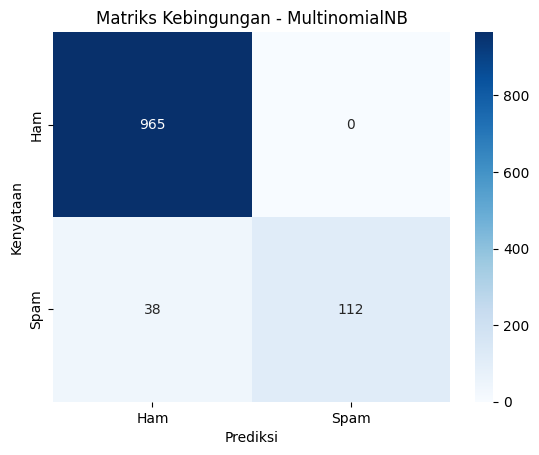

In [9]:
cm = confusion_matrix(y_test, pred_mnb)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Ham', 'Spam'], yticklabels=['Ham', 'Spam'])
plt.xlabel('Prediksi')
plt.ylabel('Kenyataan')
plt.title('Matriks Kebingungan - MultinomialNB')
plt.show()


## 9. Validasi Silang (Cross-Validation)
Kita uji kestabilan model dengan k-fold cross-validation.

In [10]:
cv_scores = cross_val_score(model_mnb, X_vec, y, cv=5)
print("Akurasi Cross-Validation (5-fold):", cv_scores)
print("Rata-rata Akurasi:", np.mean(cv_scores))


Akurasi Cross-Validation (5-fold): [0.96950673 0.96053812 0.95691203 0.96229803 0.96409336]
Rata-rata Akurasi: 0.9626696508360773
